In [79]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

control = pd.read_csv("df_control_updated.csv")
test = pd.read_csv("df_test_updated.csv")

control["visit_id"].nunique()

32180

In [80]:
control['date_time'] = pd.to_datetime(control['date_time'], format="%Y-%m-%d %H:%M:%S")
test['date_time'] = pd.to_datetime(test['date_time'], format="%Y-%m-%d %H:%M:%S")

#### CHALLENGE 1: 

During our analysis, we found that many users did not start the online process with 'start' as the first recorded step. Thus we need to find the number of users who missed the start to decide whether we need to drop them or not. If a user’s first recorded step is not “start”, it can distort funnel analysis because the user may appear to progress or convert without actually entering the funnel, leading to inaccurate conversion rates. It can also indicate tracking issues or session boundaries problems, and if it occurs at different rates between control and test groups, it may introduce bias into A/B test results.


In [83]:
#Sorting by visit_id (unique user) and by date_time so the first recorded step for each client is at  the top 

control_sorted = control.sort_values(["visit_id", "date_time"])
test_sorted = test.sort_values(["visit_id", "date_time"])


#Grouping by visit_id to get the first recorded step of each user 
control_first = control_sorted.groupby("visit_id").first()
test_first = test_sorted.groupby("visit_id").first()


#Find users whose first recorded step is not start
invalid_control = control_first[control_first["process_step"] != "start"]
invalid_test = test_first[test_first["process_step"] != "start"]

#Find the proportions for control and test of users missing start step to determine whether we should drop them or not 
print(len(invalid_control) / len(control_first))
print(len(invalid_test) / len(test_first))

0.1708514605344935
0.33589184239584174


#### SOLUTION 1: 

Our output means:

1. Control: 0.1708 → 17.1% of visits do NOT start with "start"
2. Test: 0.3359 → 33.6% of visits do NOT start with "start"

This is very high, especially for the test group. Normally in funnel/event tracking this should be close to 0–2% unless something unusual is happening. This could be for a number of reasons, users may have a first recorded step other than “start” due to tracking issues such as missing early events, page refreshes, or events being logged late and out of order. It can also happen when users enter the process mid-funnel, skipping the initial step entirely.

Since the percentage of users missing the start is too high we cannot enforce a strict funnel where we keep only visits where the first step is "start". Instead we will use a flexible funnel keeping visits that contain "start" anywhere. Keeping visits that contain “start” anywhere avoids removing valid sessions where the start event was recorded late due to tracking issues. It may slightly lower early-step completion rates but helps prevent inflated completion rates in later funnel steps.

In [40]:
def missing_start (df: pd.DataFrame) --> pd.DataFrame:
    start_users = set(df[df["process_step"] == "start"]["visit_id"])
    all_users = set(df["visit_id"])
    missing_start = all_users - start_users
    df = df[~df["visit_id"].isin(missing_start)]
    return df


start_users_control = set(control[control["process_step"] == "start"]["visit_id"])
all_users_control = set(control["visit_id"])
missing_start_control = all_users_control - start_users_control



start_users_test= set(test[test["process_step"] == "start"]["visit_id"])
all_users_test = set(test["visit_id"])
missing_start_test = all_users_test - start_users_test



control = control[~control["visit_id"].isin(missing_start_control)]
test = test[~test["visit_id"].isin(missing_start_test)]

### COMPLETION RATES BETWEEN TEST AND CONTROL GROUPS


#### What % of users finished the entire process?

To answer this question, the goal was to measure how many unique users successfully reached the final step of the process (“confirm”), and express that as a percentage of all users who started the online process.

**Approach:**

The analysis is based on two key ideas:

1. Identify total users who entered the process

2. Identify how many of those users reached the final step (“confirm”)

By comparing these two numbers, we can compute the completion rate, which represents the proportion of users who successfully finished the process. 

**Assumptions:**

In order to calculate the completion rate we assumed the following: 

1. visit_id represents a unique user
2. Reaching "confirm" = full completion but must have completed each step before reaching confirm 
3. Users are counted only once
4. All users had the opportunity to complete 

In [41]:
def completion_var(df):
    required_steps = {"start","step_1","step_2","step_3","confirm"}
    visit_steps = df.groupby("visit_id")["process_step"].apply(set)
    completed = visit_steps.apply(lambda x: required_steps.issubset(x)).sum()
    total = df["visit_id"].nunique()
    return completed, total

def completion_rate(completed: int, total: int, label=""):
    if total == 0:
        raise ZeroDivisionError ("Cannot divide by zero")
    completion_rate = (completed / total) * 100
    print(f"Completion rate {label}: {completion_rate:.2f}%")
    return completion_rate


def relative_change(control: float, test: float):
    if control == 0:
        print("Cannot compute relative change (control = 0)")
        return 0
    relative_change = ((test - control) / control) * 100
    print(f"The relative change from {control:.2f}% to {test:.2f}% is {relative_change:.2f}%")
    return relative_change


completed_test, total_test = completion_var(test)
completed_control, total_control = completion_var(control)

print(completed_test)
print(total_test)

rate_test = completion_rate(completed_test, total_test, "test group")
rate_control = completion_rate(completed_control, total_control, "control group")


print(completed_control)
print(total_control)

relative_change(rate_control, rate_test)

17713
33018
Completion rate test group: 53.65%
Completion rate control group: 47.73%
14696
30793
The relative change from 47.73% to 53.65% is 12.41%


np.float64(12.407222831524589)

In [42]:
print(completed_test)
print(total_test)

17713
33018


In [43]:
print(completed_control)
print(total_control)

14696
30793


### COMPLETION RATES WITHIN GROUPS 

#### WITHIN CONTROL GROUP 

Answers: Of users who reached "step" how many finished it?”

In [44]:
def cr_steps(df, steps, user_col="visit_id", step_col="process_step"):
    
    df_clean = df[[user_col, step_col]].drop_duplicates()
    step_users = {
        step: set(df_clean[df_clean[step_col] == step][user_col])
        for step in steps}
    
    results = []
    
    for i, step in enumerate(steps):
        current_users = step_users.get(step, set())
        
        if i == 0:
            started = len(current_users)
            completed = len(current_users)
        else:
            prev_users = step_users.get(steps[i-1], set())
            progressed = prev_users & current_users
            
            started = len(prev_users)
            completed = len(progressed)
        
        rate = completed / started if started else 0
        
        results.append({
            "step": step,
            "attempts": started,
            "completions": completed,
            "completion_rate": rate})
    
    return pd.DataFrame(results)



In [45]:
steps = ["start", "step_1", "step_2","step_3", "confirm"]
control_steps_cr = cr_steps(control, steps, "visit_id", "process_step")
print(control_steps_cr)


      step  attempts  completions  completion_rate
0    start     30793        30793         1.000000
1   step_1     30793        23169         0.752411
2   step_2     23169        19677         0.849281
3   step_3     19688        17659         0.896942
4  confirm     17738        14771         0.832732


In [46]:
#control[['client_id','visitor_id', 'visit_id','process_step','date_time']].iloc[:9,:].sort_values(by='date_time', ascending=True)

In [47]:
#control[ control['visit_id']=='795373564_99931517312_810896'][['client_id','visitor_id', 'visit_id','process_step','date_time']].sort_values(by='date_time', ascending= True)

In [48]:
#def analyze_visit_id(df: pd.DataFrame, visitid: str) -> pd.DataFrame:
    #for visitid in df["visit_id"]:
    #return df[df['visit_id']==visitid][['client_id','visitor_id', 'visit_id','process_step','date_time']].sort_values(by='date_time', ascending= True)

In [49]:
#def analyze_visits(df: pd.DataFrame) -> dict:

    #visits = {}

    #for visit_id in df["visit_id"].unique():

        #visits[visit_id] = (
            #df[df["visit_id"] == visit_id][
                #['client_id','visitor_id','visit_id','process_step','date_time']
           # ].sort_values("date_time"))

    #return visits

In [50]:
#analyze_visits(control)

In [51]:
#By looking at the completion rates for each step we found that the number of attempts for "start" was not equal to the unique number of visit_ids which we are counting as the number of unique users. This means that many users didn't start the online process from 'start'. Thus, in order to make our dataset as clean as possible we need to drop them and only count the users that began the process from "start".  


start_users = set(control[control["process_step"] == "start"]["visit_id"])
all_users = set(control["visit_id"])

missing_start = all_users - start_users

len(missing_start)

0

#### WITHIN TEST GROUP

In [52]:
test_steps_cr = cr_steps(test, steps, "visit_id", "process_step")
print(test_steps_cr)

      step  attempts  completions  completion_rate
0    start     33018        33018         1.000000
1   step_1     33018        27885         0.844539
2   step_2     27885        23974         0.859745
3   step_3     24003        21467         0.894347
4  confirm     21505        17742         0.825017


In [53]:
test["visit_id"].nunique()

33018

In [54]:
start_users_test = set(test[test["process_step"] == "start"]["visit_id"])
all_users_test = set(test["visit_id"])

missing_start_test = all_users_test - start_users_test

len(missing_start_test)

0

### HYPOTHESIS TESTING

#### TESTING COMPLETION RATE OF USERS WHO FINISHED THE WHOLE PROCESS

The introduction of a new UI design comes with its associated costs: design, development, testing, potential training for staff, and possible short-term disruptions or adjustments for users. To justify these costs, Vanguard has determined that any new design should lead to a minimum increase in the completion rate to be deemed cost-effective.

Threshold: Vanguard has set this minimum increase in completion rate at 5%. This is the rate at which the projected benefits, in terms of increased user engagement and potential revenue, are estimated to outweigh the costs of the new design.

We will be running a Z-test by: 

1. Stating the null hypothesis and alternative hypothesis.
2. Choosing an alpha level (significance level).
3. Finding the critical value of z in a z table.
4. Calculating the z test statistic
5. Comparing the test statistic to the critical z value and decide if you should support or reject the null hypothesis.


1. H0: test completion rate =< control completion rate + 0.05
2. H1: test completion rate > control completion rate + 0.05
3. Significance level: 5% (0.05)

In [55]:
P1 = rate_control/100
P2 = rate_test/100
p = (completed_control + completed_test)/(total_control + total_test)

Z = ((P2 - P1) - 0.05) / np.sqrt(p * (1 - p) * (1/total_control + 1/total_test))

print(Z)
if Z > 1.96: 
    print ("We reject the null hypothesis")
else: 
    print("We fail to reject the null hypothesis")

2.32631595211614
We reject the null hypothesis


### VISUALISATIONS

In [56]:
cr_by_steps = pd.merge(test_steps_cr, control_steps_cr, on="step", how="outer")
cr_by_steps

,step,attempts_x,completions_x,completion_rate_x,attempts_y,completions_y,completion_rate_y
0,confirm,21505,17742,0.825017,17738,14771,0.832732
1,start,33018,33018,1.000000,30793,30793,1.000000
2,step_1,33018,27885,0.844539,30793,23169,0.752411
3,step_2,27885,23974,0.859745,23169,19677,0.849281
4,step_3,24003,21467,0.894347,19688,17659,0.896942


In [57]:
cr_by_steps = cr_by_steps.drop(["attempts_x", "completions_x", "attempts_y", "completions_y"], axis=1)
cr_by_steps = cr_by_steps.rename(columns={'completion_rate_x': 'completion_rate_test', 'completion_rate_y': 'completion_rate_control'})

In [58]:
cr_by_steps

,step,completion_rate_test,completion_rate_control
0,confirm,0.825017,0.832732
1,start,1.000000,1.000000
2,step_1,0.844539,0.752411
3,step_2,0.859745,0.849281
4,step_3,0.894347,0.896942


### COMPARING COMPLETION RATES BETWEEN GROUPS AT EACH STEP 

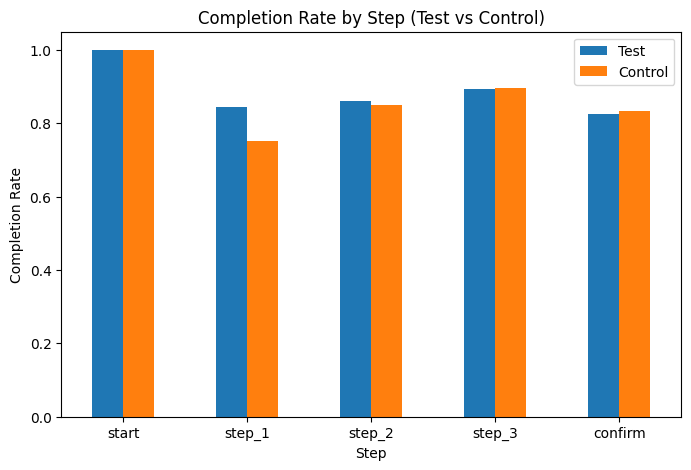

In [59]:
order = ["start", "step_1", "step_2", "step_3", "confirm"]

cr_by_steps["step"] = pd.Categorical(
    cr_by_steps["step"],
    categories=order,
    ordered=True)

cr_by_steps = cr_by_steps.sort_values("step")

cr_by_steps.set_index("step").plot(kind="bar", figsize=(8,5))

plt.ylabel("Completion Rate")
plt.xlabel("Step")
plt.title("Completion Rate by Step (Test vs Control)")
plt.xticks(rotation=0)
plt.legend(["Test", "Control"])

plt.show()

#### CALCULATING DROP-OFF RATE PER STEP 

In [60]:
cr_by_steps["dropoff_test"] = 1 - cr_by_steps["completion_rate_test"]
cr_by_steps["dropoff_control"] = 1 - cr_by_steps["completion_rate_control"]

In [61]:
cr_by_steps

,step,completion_rate_test,completion_rate_control,dropoff_test,dropoff_control
1,start,1.000000,1.000000,0.000000,0.000000
2,step_1,0.844539,0.752411,0.155461,0.247589
3,step_2,0.859745,0.849281,0.140255,0.150719
4,step_3,0.894347,0.896942,0.105653,0.103058
0,confirm,0.825017,0.832732,0.174983,0.167268


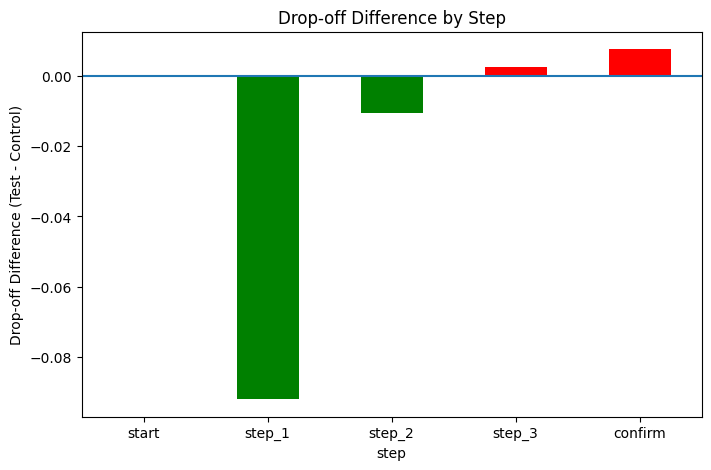

In [62]:

cr_by_steps["dropoff_diff"] = (cr_by_steps["dropoff_test"] - cr_by_steps["dropoff_control"])
colors = ["green" if x < 0 else "red" for x in cr_by_steps["dropoff_diff"]]
cr_by_steps.set_index("step")["dropoff_diff"].plot(kind="bar", color=colors,figsize=(8,5))

plt.axhline(0)
plt.ylabel("Drop-off Difference (Test - Control)")
plt.title("Drop-off Difference by Step")
plt.xticks(rotation=0)

plt.show()

The experiment significantly reduces drop-off at step_1 (~9%), suggesting the new design improves initial engagement. Later funnel steps show minimal differences, and the final confirmation step slightly underperforms in the test group

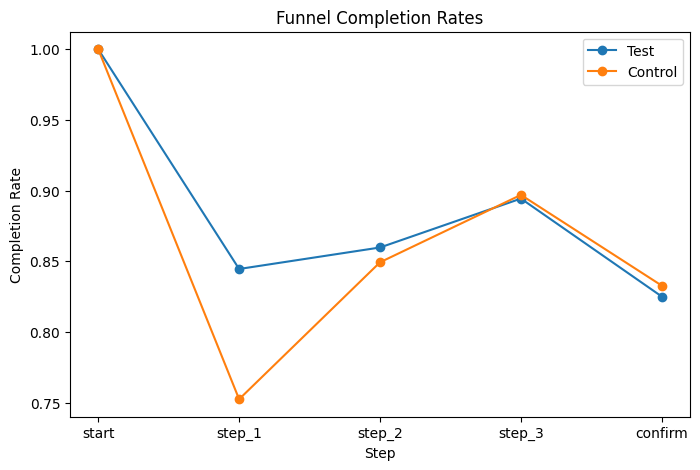

In [63]:
plt.figure(figsize=(8,5))

plt.plot(cr_by_steps["step"], cr_by_steps["completion_rate_test"], marker="o", label="Test")
plt.plot(cr_by_steps["step"], cr_by_steps["completion_rate_control"], marker="o", label="Control")

plt.ylabel("Completion Rate")
plt.xlabel("Step")
plt.title("Funnel Completion Rates")
plt.legend()

plt.show()

The test group performs much better at step_1, with about 9% more users continuing compared to the control group. After that, the two groups behave very similarly. At the final confirmation step, the control group performs slightly better, but the difference is small. Overall, the test mainly improves the first step of the funnel.

In [64]:
# Two-proportion z-test to check whether the improvement at step_1 is real or just due to random variation using a significance level of 5%
# H0: p(test) =< p(control) --> New website design does not improve step 1 completion 
# H1: p(test) > p(control) --> New website design does improve step 1 completion 


P_1 = 27885/33018
P_2 = 23169/30793
p1 = (27885 + 23169)/(33018 + 30793)

Z1 = ((P_2 - P_1) - 0.05) / np.sqrt(p1 * (1 - p1) * (1/30793 + 1/33018))

print(Z)
if Z > 1.96: 
    print ("We reject the null hypothesis")
else: 
    print("We fail to reject the null hypothesis")

2.32631595211614
We reject the null hypothesis


We reject the null hypothesis meaning the new website significantly improves step_1 completion 

In [65]:
cr_by_steps.to_csv("cr_by_steps.csv")

In [66]:
df_combined = pd.concat([control, test])
df_combined.to_csv("df_combined.csv", index=False)

### You might want to test if the average client tenure (how long they've been with Vanguard) of those engaging with the new process is the same as those engaging with the old process

In [67]:
control1 = pd.read_csv("df_control_updated.csv")
test1 = pd.read_csv("df_test_updated.csv")

In [68]:
control1.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,visitor_id,visit_id,process_step,date_time
0,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,start,2017-04-08 18:51:28
1,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:52:17
2,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:53:20
3,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 18:53:29
4,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_3,2017-04-08 18:58:04


In [69]:
cr_steps1 = pd.merge(test_steps_cr, control_steps_cr, on="step", how="outer")

In [70]:
cr_steps1

,step,attempts_x,completions_x,completion_rate_x,attempts_y,completions_y,completion_rate_y
0,confirm,21505,17742,0.825017,17738,14771,0.832732
1,start,33018,33018,1.000000,30793,30793,1.000000
2,step_1,33018,27885,0.844539,30793,23169,0.752411
3,step_2,27885,23974,0.859745,23169,19677,0.849281
4,step_3,24003,21467,0.894347,19688,17659,0.896942


In [71]:
cr_steps1 = cr_steps1.rename(columns={'completion_rate_x': 'completion_rate_test', 'completion_rate_y': 'completion_rate_control', "attempts_x": "attempts_test", "attempts_y": "attempts_control", "completions_x": "completions_test", "completions_y": "completions_control"})

In [112]:
cr_steps1["dropoff_test"] = 1 - cr_steps1["completion_rate_test"]
cr_steps1["dropoff_control"] = 1 - cr_steps1["completion_rate_control"]

cr_steps1

,step,attempts_test,completions_test,completion_rate_test,attempts_control,completions_control,completion_rate_control,dropoff_test,dropoff_control
0,confirm,21505,17742,0.825017,17738,14771,0.832732,0.174983,0.167268
1,start,33018,33018,1.000000,30793,30793,1.000000,0.000000,0.000000
2,step_1,33018,27885,0.844539,30793,23169,0.752411,0.155461,0.247589
3,step_2,27885,23974,0.859745,23169,19677,0.849281,0.140255,0.150719
4,step_3,24003,21467,0.894347,19688,17659,0.896942,0.105653,0.103058


In [75]:
cr_steps1.to_csv("cr_steps1.csv", index=False)

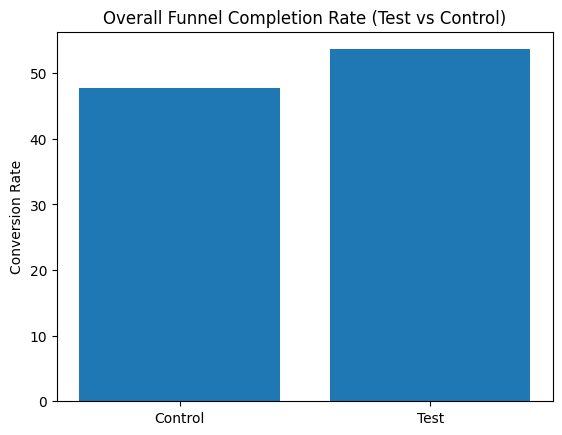

In [77]:

labels = ["Control", "Test"]
rates = [rate_control, rate_test]

plt.bar(labels, rates)
plt.ylabel("Conversion Rate")
plt.title("Overall Funnel Completion Rate (Test vs Control)")
plt.show()

In [105]:
error_rate = pd.read_csv("/Users/victoriacano/Downloads/error_rate_by_step_tableau.csv")

In [106]:
error_rate.head()

,process_step,Control,Test,Improvement
0,confirm,0.000000,0.000000,NaN
1,start,0.101117,0.186174,-0.841167
2,step_1,0.077659,0.088114,-0.134620
3,step_2,0.091439,0.073833,0.192551
4,step_3,0.005703,0.001120,0.803621


In [107]:
error_rate["Absolute_difference"] = (error_rate["Control"] - error_rate["Test"])

# Handle division by zero
error_rate.loc[error_rate["Control"] == 0, "Improvement"] = None

print(error_rate)

  process_step   Control      Test  Improvement  Absolute_difference
0      confirm  0.000000  0.000000          NaN             0.000000
1        start  0.101117  0.186174    -0.841167            -0.085057
2       step_1  0.077659  0.088114    -0.134620            -0.010454
3       step_2  0.091439  0.073833     0.192551             0.017607
4       step_3  0.005703  0.001120     0.803621             0.004583


In [109]:
error_rate.to_csv("/Users/victoriacano/Downloads/error_rate.csv", index=True)

In [110]:
combined = pd.merge(control, test, on="client_id", how="outer")

In [111]:
combined.to_csv("/Users/victoriacano/Downloads/combined.csv", index=True)